In [200]:
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import sklearn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import os
import sys
import json
from pathlib import Path

In [201]:
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print('Python: ',sys.version)

pandas version: 2.3.3
numpy version: 2.3.5
scikit-learn version: 1.8.0
Python:  3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [151]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)

device: cpu
torch: 2.10.0+cpu


In [110]:
df = pd.read_csv("S12-hw-dataset.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [111]:
print("Число наблюдений: ",df.shape[0])

Число наблюдений:  4320


In [112]:
print("Диапазон дат:",df['date'][0]," - ",df['date'][4319])

Диапазон дат: 2025-01-01 00:00:00  -  2025-06-29 23:00:00


In [113]:
print("Пропуски по столбцам: ")
print(df.isnull().sum())

Пропуски по столбцам: 
date      0
target    0
dtype: int64


пропуски отсутвуют!

Визуализация датасета как временного ряда

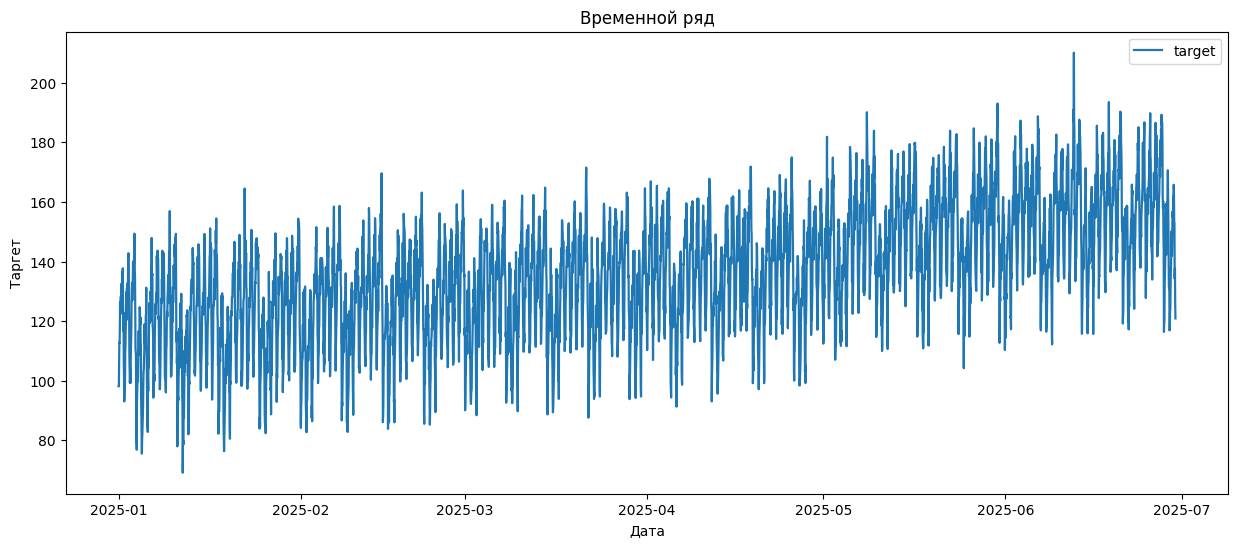

In [114]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df["date"], df["target"], lw=1.6, label="target")
ax.set_title("Временной ряд")
ax.set_xlabel("Дата")
ax.set_ylabel("Таргет")
ax.legend()
plt.show()

наблюдаем выбросы ,4 из которых особенно явные, особенно в конце; увелечение таргета с каждым месяцем,и более явное во второй половине временного диапозона

In [214]:
# Небольшие вспомогательные функции для единообразной оценки всех моделей.
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])

разбиение данных на train / validation / test по времени

train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


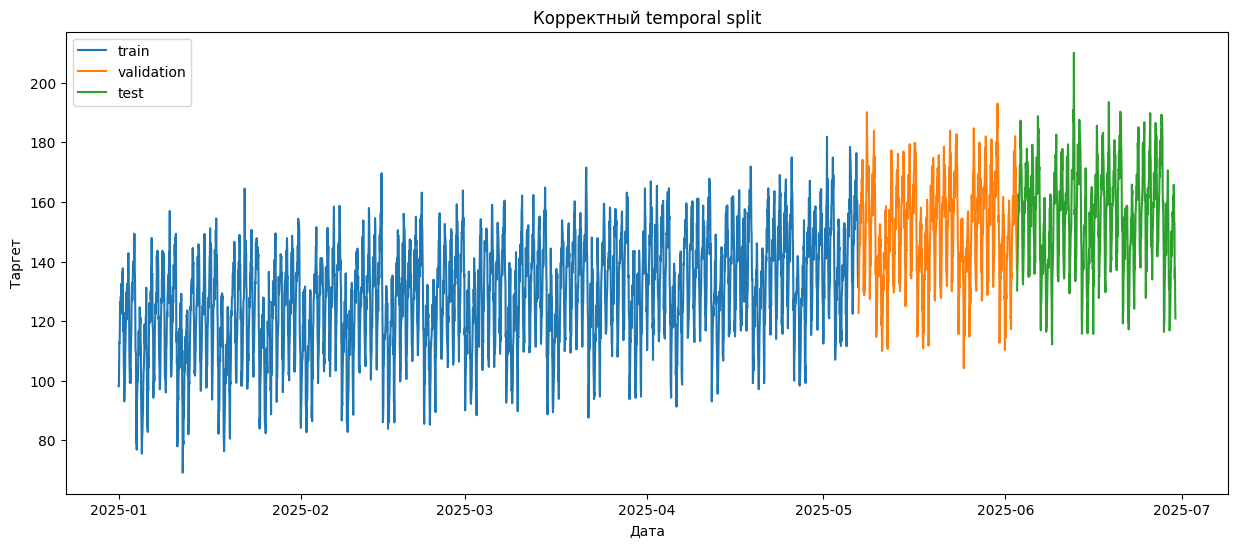

In [168]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    # Проверяем, что доли действительно покрывают весь датасет.
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    # Ключевая идея: train, validation и test идут по времени друг за другом.
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректный temporal split")
ax.set_xlabel("Дата")
ax.set_ylabel("Таргет")
ax.legend()
plt.savefig("artifacts/figures/series_split.png", dpi=100,bbox_inches='tight')
plt.show()

random split для данной задачи некорректен тк мы работаем с временем и подаем его на вход последовательно и четко разделяем прошлое и будущее , поэтому модель не должна видеть будущее, а при random split разбиении будет утечка данных и модель сможет "подглядеть" в будущее , тем самым увеличив себе точность

B1 (naive-last): наивный baseline, где прогноз равен последнему известному значению

In [216]:
# Naive baseline: завтрашнее значение равно последнему наблюдённому.

val_pred_naive = np.full(len(val_df), train_df['target'].iloc[-1])
baseline_results_val = pd.concat([
    evaluate_regression(val_df['target'], val_pred_naive, "Naive (lag_1)"),
], ignore_index=True).sort_values("MAE")

print("Validation:")
display(baseline_results_val)

Validation:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),20.340093,24.364325,12.856044


B2 (moving-average): baseline на основе скользящего среднего по окну разумного размера.

In [217]:
# Moving average baseline: вместо одного прошлого значения берём короткое среднее окно.
window_size = 7
val_pred_ma7 = []
hist = train_df['target'].iloc[-window_size:].tolist()

for _ in val_df['target']:
    pred = np.mean(hist)
    val_pred_ma7.append(pred)
    hist = hist[1:] + [pred]

val_pred_ma7 = np.array(val_pred_ma7)

baseline_results_val = pd.concat([
    evaluate_regression(val_df['target'], val_pred_ma7, "MovingAverage(7)"),
], ignore_index=True).sort_values("MAE")

print("Validation:")
display(baseline_results_val)

Validation:


,model,MAE,RMSE,MAPE_%
0,MovingAverage(7),16.05051,19.305568,10.443998


признаки для B3

In [116]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки часто дают модели простую и полезную сезонную структуру.
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month

    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    # Лаги смотрят только назад во времени и поэтому безопасны с точки зрения leakage.
    for lag in [1,7,14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)

# Первые строки неизбежно теряются из-за лагов и rolling-окон.
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()


,date,target,dayofweek,month,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2025-01-01 14:00:00,128.87,2,1,125.04,126.01,98.14,126.445714,3.275621
1,2025-01-01 15:00:00,136.40,2,1,128.87,122.38,98.07,126.854286,3.388632
2,2025-01-01 16:00:00,133.85,2,1,136.40,128.28,104.70,128.857143,4.318919
3,2025-01-01 17:00:00,137.71,2,1,133.85,124.43,112.81,129.652857,4.691868
4,2025-01-01 18:00:00,126.32,2,1,137.71,126.35,112.62,131.550000,4.907936


In [152]:
# Собираем финальный набор признаков для baseline-моделей.
feature_cols = [
    "dayofweek", "month",
    "lag_1","lag_7","lag_14",
    "rolling_mean_7", "rolling_std_7",
]

target_col = "target"

# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (3014, 7) | y_train: (3014,)
X_val:   (646, 7) | y_val:   (646,)
X_test:  (646, 7) | y_test:  (646,)


B3 (ridge-lag-features): Ridge на лаговых, rolling- и календарных признаках.

In [156]:
# Ridge чувствителен к масштабу признаков, поэтому его обучаем на стандартизованных данных.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)

val_results = pd.concat([
    evaluate_regression(y_val, val_pred_ridge, "Ridge"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

print("Validation:")
display(val_results)

Validation:


,model,MAE,RMSE,MAPE_%
0,Ridge,6.464618,8.05106,4.324476


Оконное представление для GRU

In [157]:
# 1. Нормализация данных ТОЛЬКО по train набору (чтобы не было утечки информации)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          # transform для val/test
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

window_size = 28  # Глубина контекста: модель смотрит на 28 дней в прошлое

def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [day1..day28], y = day29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 28
        y.append(series_2d[i + window_size, 0])         # Цель: день 29
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем обучающие примеры для каждого набора
X_train_GRU, y_train_GRU = make_windows(train_scaled, window_size)
X_val_GRU, y_val_GRU = make_windows(val_scaled, window_size)
X_test_GRU, y_test_GRU = make_windows(test_scaled, window_size)

print("X_train:", X_train_GRU.shape, "y_train:", y_train_GRU.shape)
print("X_val  :", X_val_GRU.shape, "y_val  :", y_val_GRU.shape)
print("X_test :", X_test_GRU.shape, "y_test :", y_test_GRU.shape)

X_train: (2996, 28, 1) y_train: (2996,)
X_val  : (620, 28, 1) y_val  : (620,)
X_test : (620, 28, 1) y_test : (620,)


In [158]:
# Определяем PyTorch Dataset для обработки последовательностей
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  # Размер батча для градиентного спуска

# Создаем датасеты для каждого набора
train_ds = TimeSeriesDataset(X_train_GRU, y_train_GRU)
val_ds = TimeSeriesDataset(X_val_GRU, y_val_GRU)
test_ds = TimeSeriesDataset(X_test_GRU, y_test_GRU)

# Создаем DataLoaders для итерирования по батчам
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # train перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверяем форму батча
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,

Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])


цикл обучения для RNN

In [141]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

R1 (gru-forecast): GRU на оконном представлении ряда.

In [142]:
class GRUForecaster(nn.Module):
    """
    GRU-модель для временных рядов.
    GRU проще, чем LSTM: имеет 2 вентиля (reset и update) вместо 3, нет cell state.
    Часто работает лучше на малых датасетах благодаря меньшей сложности оптимизации.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

In [143]:
@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()

def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

In [144]:
# Обучаем GRU с увеличенной емкостью (hidden_size=64, num_layers=2)
# и медленной скоростью обучения (lr=5e-4) на 30 эпох
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

GRU  params: 37889
Epoch 01 | train_loss=0.7014 | val_loss=0.7001
Epoch 02 | train_loss=0.2763 | val_loss=0.3388
Epoch 03 | train_loss=0.1606 | val_loss=0.1872
Epoch 04 | train_loss=0.1546 | val_loss=0.2356
Epoch 05 | train_loss=0.1490 | val_loss=0.1927
Epoch 06 | train_loss=0.1487 | val_loss=0.1861
Epoch 07 | train_loss=0.1489 | val_loss=0.2256
Epoch 08 | train_loss=0.1484 | val_loss=0.2114
Epoch 09 | train_loss=0.1443 | val_loss=0.2075
Epoch 10 | train_loss=0.1442 | val_loss=0.2457
Epoch 11 | train_loss=0.1428 | val_loss=0.2012
Epoch 12 | train_loss=0.1405 | val_loss=0.2374
Epoch 13 | train_loss=0.1389 | val_loss=0.1950
Epoch 14 | train_loss=0.1327 | val_loss=0.1880
Epoch 15 | train_loss=0.1231 | val_loss=0.2458
Epoch 16 | train_loss=0.1115 | val_loss=0.2077
Epoch 17 | train_loss=0.1069 | val_loss=0.1753
Epoch 18 | train_loss=0.1059 | val_loss=0.2515
Epoch 19 | train_loss=0.1030 | val_loss=0.1669
Epoch 20 | train_loss=0.1040 | val_loss=0.1978
Epoch 21 | train_loss=0.1018 | val_loss=0

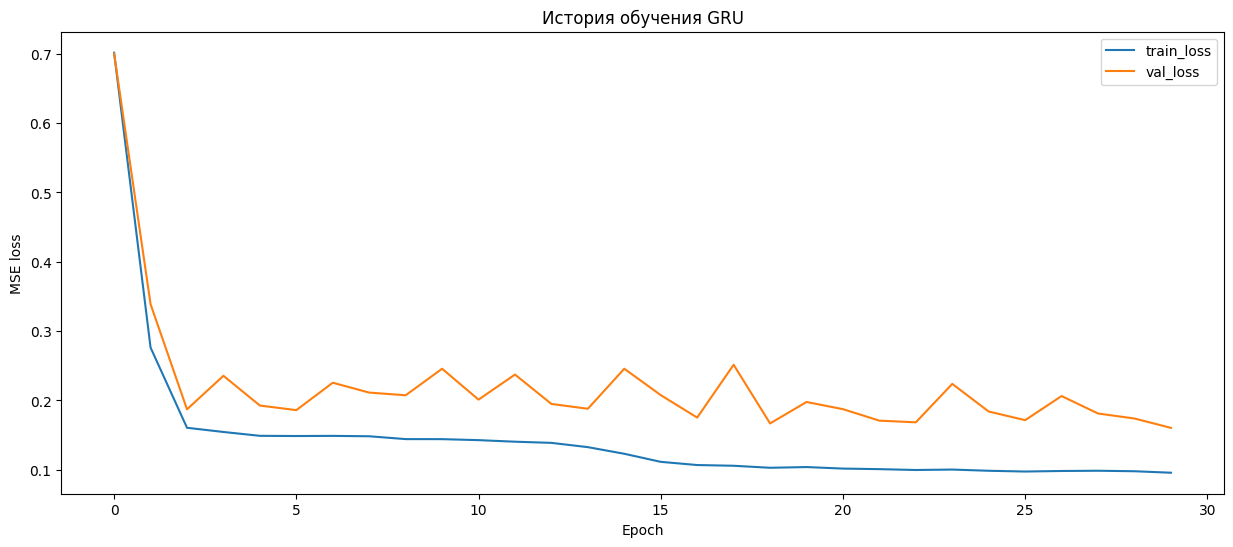

In [170]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig("artifacts/figures/gru_learning_curves.png", dpi=100,bbox_inches='tight')
plt.show()

In [159]:
gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)

# Восстанавливаем исходный масштаб
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)
val_true = inverse_scale(gru_val_true_scaled, scaler)

val_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(val_true, gru_val_pred)},
    ]
).sort_values("MAE")

val_metrics

,model,MAE,RMSE,MAPE
0,GRU,5.724288,7.437093,3.819143


Находим лучшую модель по MAE

In [211]:
val_metrics = pd.DataFrame(
    [
        {"model": "MovingAverage baseline", **regression_metrics(val_df['target'], val_pred_ma7)},
        {"model": "Naive baseline", **regression_metrics(val_df['target'], val_pred_naive)},
        {"model": "Ridge baseline", **regression_metrics(y_val, val_pred_ridge)},
        {"model": "GRU", **regression_metrics(val_true, gru_val_pred)},
    ]
).sort_values("MAE")

val_metrics

,model,MAE,RMSE,MAPE
3,GRU,5.724288,7.437093,3.819143
2,Ridge baseline,6.464618,8.051060,4.324476
0,MovingAverage baseline,16.050510,19.305568,10.443998
1,Naive baseline,20.340093,24.364325,12.856044


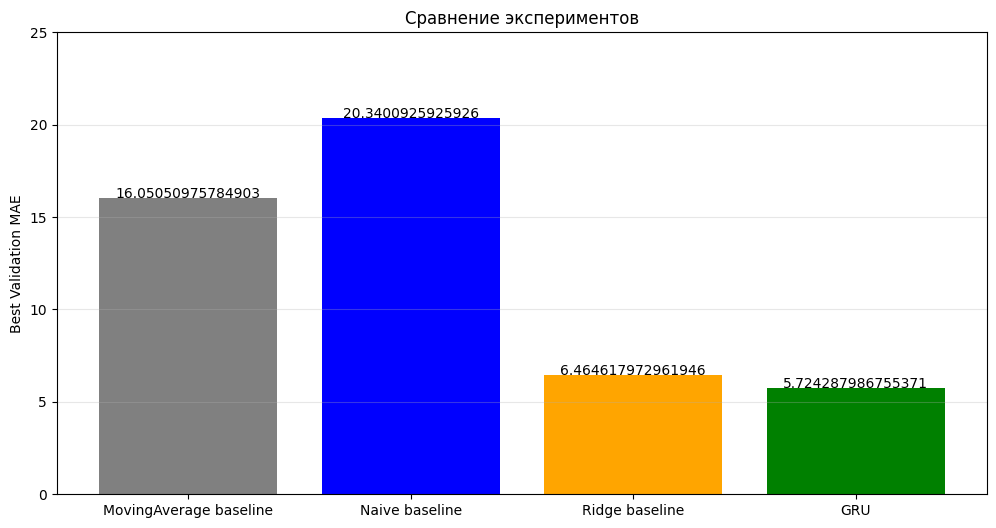

In [213]:
experiments = ['MovingAverage baseline', 'Naive baseline', 'Ridge baseline', 'GRU']
accuracies = [val_metrics["MAE"][0],val_metrics["MAE"][1],val_metrics["MAE"][2],val_metrics["MAE"][3]]

plt.figure(figsize=(12, 6))
bars = plt.bar(experiments, accuracies, color=['gray', 'blue', 'orange', 'green'])

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc}', ha='center', fontsize=10)

plt.ylabel('Best Validation MAE')
plt.title('Сравнение экспериментов')
plt.ylim(0, 25)
plt.grid(axis='y', alpha=0.3)
plt.savefig("artifacts/figures/baselines_compare.png", dpi=100,bbox_inches='tight')
plt.show()

In [161]:
best_model_name = val_metrics.iloc[0]["model"]
print("Лучшая модель на val:", best_model_name)

Лучшая модель на val: GRU


In [162]:
gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)

# Восстанавливаем исходный масштаб
test_true = inverse_scale(gru_test_true_scaled, scaler)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler)

# Вычисляем финальные метрики
test_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(test_true, gru_test_pred)},
    ]
).sort_values("RMSE")

test_metrics

,model,MAE,RMSE,MAPE
0,GRU,6.92251,8.788505,4.424775


In [218]:
experiments_results = []

def add_experiment(experiment_id,split_summary,model_summary,best_val_mae,best_val_rmse,best_val_mape,notes,
                   task = "forecasting" ,dataset = "S12-hw-dataset.csv", seed=42,window_size = None,horizon= 1,
                   features_summary = 1,scaler = None,optimizer = None, lr = None, epochs_trained = None,
                   test_mae = None,test_rmse = None,test_mape = None):
    
    experiments_results.append({
        "experiment_id": experiment_id,
        "task": task,
        "dataset": dataset,
        "seed": seed,
        "split_summary": split_summary,
        "window_size": window_size,
        "horizon": horizon,
        "model_summary": model_summary,
        "features_summary": features_summary,
        "scaler": scaler,
        "optimizer": optimizer,
        "lr": lr,
        "epochs_trained": epochs_trained,
        "best_val_mae": best_val_mae,
        "best_val_rmse": best_val_rmse,
        "best_val_mape": best_val_mape,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_mape": test_mape,
        "notes": notes
    })

add_experiment("B1","train=3024,val=648,test=648","lag_1",val_metrics["MAE"][1],val_metrics["RMSE"][1],val_metrics["MAPE"][1],
               "прогноз равен последнему известному значению")
add_experiment("B2","train=3024,val=648,test=648","rolling_mean_7",val_metrics["MAE"][0],val_metrics["RMSE"][0],val_metrics["MAPE"][0],
               "baseline на основе скользящего среднего по окну разумного размера",window_size = 7)
add_experiment("B3","train=3014,val=646,test=646","Ridge(alpha=1.0)",val_metrics["MAE"][2],val_metrics["RMSE"][2],val_metrics["MAPE"][2],
               "линейная модель с L2-регуляризацией",scaler = "StandardScaler",features_summary = 7) 
add_experiment("R1","train=2996,val=620,test=620","model_type: GRUForecaster,input_size: 1,num_layers: 2,dropout: 0.0,total_params: 37889",
               val_metrics["MAE"][3],val_metrics["RMSE"][3],val_metrics["MAPE"][3],"GRU на оконном представлении ряда",
               scaler ="StandardScaler",optimizer = "Adam",lr = 5e-4, epochs_trained =  30, window_size = 28,
               test_mae = test_metrics["MAE"][0],test_rmse = test_metrics["RMSE"][0],test_mape = test_metrics["MAPE"][0])   

df_results = pd.DataFrame(experiments_results)
df_results.to_csv("artifacts/runs.csv", index=False)

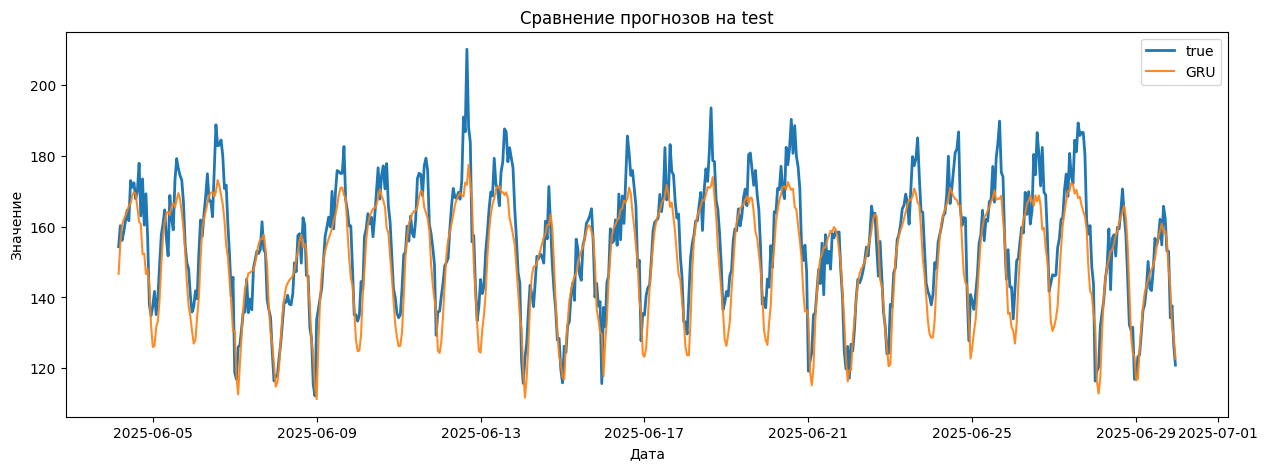

In [186]:
plot_df = pd.DataFrame(
    {
        "date": test_df["date"].iloc[window_size:].reset_index(drop=True),
        "true": test_true,
        "gru": gru_test_pred,
    }
)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["gru"], label="GRU", alpha=0.9)
ax.set_title("Сравнение прогнозов на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig("artifacts/figures/best_forecast_test.png", dpi=100,bbox_inches='tight')
plt.show()

In [165]:
# сохранение лучшей модели (R1)

tmp_path = 'artifacts/best_gru.pt'
torch.save(gru_model.state_dict(), tmp_path)
print('saved to', tmp_path, 'size:', os.path.getsize(tmp_path), 'bytes')

saved to artifacts/best_gru.pt size: 155605 bytes


In [166]:
# функция для сохранения файлов формата json
def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

In [167]:
# конфиг лучшей модели
best_config = {
    "architecture": {
        "model_type": "GRUForecaster",
        "input_size": 1,
        "num_layers": 2,
        "dropout": 0.0,
        "output_size": 1,
        "total_params": 37889
    },
    "window_size": 28,
    "hidden_size": 64,
    "batch size": 64,
    "learning rate": 5e-4,
    "seed": 42,  
    "scaler": "StandardScaler"
}

save_json(best_config, Path("artifacts/best_gru_config.json"))